# Lecture Week 8: Data Analysis (Time-Series Data)

In [3]:
import pandas as pd
import seaborn as sns

## How to generate time periods

`pd.date_range()` returns the range of equally spaced time points.

If freq is positive, the points satisfy start $<[=] x <[=]$ end and if `freq` is negative, the points satisfy end $<[=] x <[=]$ start.

In [5]:
# Create a monthly date range from '01/01/2020' to '12/31/2020' with a frequency of month starts
monthly_starts = pd.date_range(start = '01-01-2020',
                               end = '12/31/2020', # both / and - for dates are acceptable
                               freq='MS' # default ‘D’
                              ) # month starts
# Print the month starts in the date range
print(monthly_starts)


# Order matters
# monthly_starts = pd.date_range('12/31/2020', 
#                                '01/01/2020',
#                                freq='MS') # month starts
# print(monthly_starts) -> empty 

DatetimeIndex(['2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01',
               '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01'],
              dtype='datetime64[us]', freq='MS')


In [6]:
# Create a business day date range from '01/01/2020' to '01/31/2020' with a frequency of business days
business_days = pd.date_range('01/01/2020', '01/31/2020', freq='B')# business days 
# business_days = pd.date_range('01/31/2020', '01/01/2020', freq='-1B') # negative fre: start>end
# Print the business days in the date range
print(business_days)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-06',
               '2020-01-07', '2020-01-08', '2020-01-09', '2020-01-10',
               '2020-01-13', '2020-01-14', '2020-01-15', '2020-01-16',
               '2020-01-17', '2020-01-20', '2020-01-21', '2020-01-22',
               '2020-01-23', '2020-01-24', '2020-01-27', '2020-01-28',
               '2020-01-29', '2020-01-30', '2020-01-31'],
              dtype='datetime64[us]', freq='B')


In [7]:
# Create a weekly date range from '12/01/2020' to '12/31/2020' with a frequency of Mondays
mondays = pd.date_range('12/01/2020', '12/31/2020', freq='W-MON')# weekly-Mondays
# Print the Mondays in the date range
print(mondays)

DatetimeIndex(['2020-12-07', '2020-12-14', '2020-12-21', '2020-12-28'], dtype='datetime64[us]', freq='W-MON')


In [8]:
# Create a date range from '01/01/2020' to '01/31/2020' with a frequency of 12 hours
hours_12 = pd.date_range('01/01/2020', '01/31/2020', freq='12h')
print(hours_12)

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 12:00:00',
               '2020-01-02 00:00:00', '2020-01-02 12:00:00',
               '2020-01-03 00:00:00', '2020-01-03 12:00:00',
               '2020-01-04 00:00:00', '2020-01-04 12:00:00',
               '2020-01-05 00:00:00', '2020-01-05 12:00:00',
               '2020-01-06 00:00:00', '2020-01-06 12:00:00',
               '2020-01-07 00:00:00', '2020-01-07 12:00:00',
               '2020-01-08 00:00:00', '2020-01-08 12:00:00',
               '2020-01-09 00:00:00', '2020-01-09 12:00:00',
               '2020-01-10 00:00:00', '2020-01-10 12:00:00',
               '2020-01-11 00:00:00', '2020-01-11 12:00:00',
               '2020-01-12 00:00:00', '2020-01-12 12:00:00',
               '2020-01-13 00:00:00', '2020-01-13 12:00:00',
               '2020-01-14 00:00:00', '2020-01-14 12:00:00',
               '2020-01-15 00:00:00', '2020-01-15 12:00:00',
               '2020-01-16 00:00:00', '2020-01-16 12:00:00',
               '2020-01-

## How to reindex with datetime indexes

In [10]:
# Get stock data from a CSV file
stockData_1 = pd.read_csv('AAPL.csv', usecols=['Date','Open','High','Low','Close'])
print(stockData_1.Date.dtype) # str

stockData = pd.read_csv('AAPL.csv', usecols=['Date','Open','High','Low','Close'], 
                        parse_dates=['Date'] # convert selected columns into pandas datetime 
                       )
print(stockData.Date.dtype) # datetime64[us]
display(stockData.head(5))

# Set the 'Date' column as the index in the stockData DataFrame
stockData.set_index('Date', inplace=True)
display(stockData.head(10))

str
datetime64[us]


,Date,Open,High,Low,Close
0,2020-01-02,74.059998,75.150002,73.797501,75.087502
1,2020-01-03,74.287498,75.144997,74.125000,74.357498
2,2020-01-06,73.447502,74.989998,73.187500,74.949997
3,2020-01-07,74.959999,75.224998,74.370003,74.597504
4,2020-01-08,74.290001,76.110001,74.290001,75.797501


,Open,High,Low,Close
Date,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502
2020-01-03,74.287498,75.144997,74.125000,74.357498
2020-01-06,73.447502,74.989998,73.187500,74.949997
2020-01-07,74.959999,75.224998,74.370003,74.597504
2020-01-08,74.290001,76.110001,74.290001,75.797501
2020-01-09,76.809998,77.607498,76.550003,77.407501
2020-01-10,77.650002,78.167503,77.062500,77.582497
2020-01-13,77.910004,79.267502,77.787498,79.239998
2020-01-14,79.175003,79.392502,78.042503,78.169998


In [11]:
# Generate a date range for Fridays between '01/01/2020' and '12/31/2020' with a frequency of 'W-FRI'
fridays = pd.date_range('01/01/2020', '12/31/2020', freq='W-FRI')
print(fridays[:3])

DatetimeIndex(['2020-01-03', '2020-01-10', '2020-01-17'], dtype='datetime64[us]', freq='W-FRI')


In [12]:
# Reindex the stockData DataFrame using the generated date range for Fridays
stockData.reindex(fridays).head()

,Open,High,Low,Close
2020-01-03,74.287498,75.144997,74.125000,74.357498
2020-01-10,77.650002,78.167503,77.062500,77.582497
2020-01-17,79.067497,79.684998,78.750000,79.682503
2020-01-24,80.062500,80.832497,79.379997,79.577499
2020-01-31,80.232498,80.669998,77.072502,77.377502


- Existing matching dates → their data is retained.
  
- New dates not previously present → new rows containing NaN.
  
- Old dates not included in new_dates → those rows are removed.
  
- Rows are reordered according to new_dates.

## How to reindex with a semi-month index

,Open,High,Low,Close
Date,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502
2020-01-03,74.287498,75.144997,74.125000,74.357498
2020-01-06,73.447502,74.989998,73.187500,74.949997
2020-01-07,74.959999,75.224998,74.370003,74.597504
2020-01-08,74.290001,76.110001,74.290001,75.797501


semiMonths:
DatetimeIndex(['2020-01-01', '2020-01-15', '2020-02-01', '2020-02-15',
               '2020-03-01', '2020-03-15', '2020-04-01', '2020-04-15',
               '2020-05-01', '2020-05-15', '2020-06-01', '2020-06-15',
               '2020-07-01', '2020-07-15', '2020-08-01', '2020-08-15',
               '2020-09-01', '2020-09-15', '2020-10-01', '2020-10-15',
               '2020-11-01', '2020-11-15', '2020-12-01', '2020-12-15'],
              dtype='datetime64[us]', freq='SMS-15')


DatetimeIndex(['2020-01-01', '2020-01-15', '2020-02-01', '2020-02-15'], dtype='datetime64[us]', freq='SMS-15')

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875000,77.387497,77.834999
2020-02-01,NaN,NaN,NaN,NaN
2020-02-15,NaN,NaN,NaN,NaN
2020-03-01,NaN,NaN,NaN,NaN
2020-03-15,NaN,NaN,NaN,NaN
2020-04-01,61.625000,62.180000,59.782501,60.227501
2020-04-15,70.599998,71.582497,70.157501,71.107498
2020-05-01,71.562500,74.750000,71.462502,72.267502
2020-05-15,75.087502,76.974998,75.052498,76.927498


<Axes: >

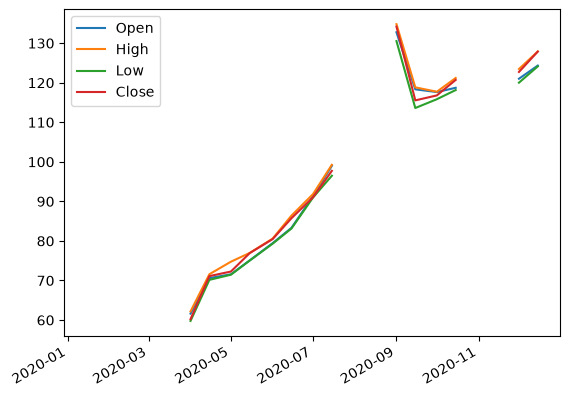

In [15]:
display(stockData.head())
# Generate a date range for semi-monthly dates between '01/01/2020' and '12/31/2020'
semiMonths = pd.date_range('01/01/2020', '12/31/2020', freq='SMS') # semi-monthly start
print(f'semiMonths:\n{semiMonths}')
# Reindex the stockData DataFrame using the generated date range for semi-monthly dates
stockData_reindexed = stockData.reindex(semiMonths)
display(semiMonths[:4])
display(stockData_reindexed.head(20))
stockData_reindexed.plot()
# The datetime index for the x-axis
# The numerical columns for the y-axis
# A separate line for each numerical column

## How a user-defined function can improve a datetime index

In [17]:
import datetime as dt

def adjustDate(date):
    # Check if the weekday of the given date is less than 5 (Monday to Friday)
    if date.weekday() < 5: # date.weekday() returns the day of the week as an integer: 0->Monday
                           # One Python datetime value: date.weekday()
        return date
    # If the weekday is Saturday (5), subtract 1 day to get the previous Friday
    elif date.weekday() == 5:
        return date - dt.timedelta(days=1) # Pandas datetime column: df['date'].dt.weekday
    # If the weekday is Sunday (6), add 1 day to get the following Monday
    else:
        return date + dt.timedelta(days=1)

In [18]:
semiMonths = pd.date_range('01/01/2020', '12/31/2020', freq='SMS')
# Convert semiMonths (DateTimeIndex) to a pandas Series & apply the adjustDate function to each date
semiMonthsAdjusted = semiMonths.to_series().apply(adjustDate)
# Reindex the stockData DataFrame using the adjusted semiMonths dates
display(stockData.reindex(semiMonthsAdjusted).head(4))

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875000,77.387497,77.834999
2020-01-31,80.232498,80.669998,77.072502,77.377502
2020-02-14,81.184998,81.495003,80.712502,81.237503


## How reindexing with an improved index can improve plots

In [20]:
# Reindex the stockData DataFrame using the original semiMonths dates
# obtained from the semiMonths date range
stockData.reindex(semiMonths).head()

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875,77.387497,77.834999
2020-02-01,NaN,NaN,NaN,NaN
2020-02-15,NaN,NaN,NaN,NaN
2020-03-01,NaN,NaN,NaN,NaN


In [21]:
# Reindex the stockData DataFrame using the semiMonthsAdjusted dates
# obtained after applying the adjustDate function to the semiMonths dates
stockData.reindex(semiMonthsAdjusted).head()

,Open,High,Low,Close
2020-01-01,NaN,NaN,NaN,NaN
2020-01-15,77.962502,78.875000,77.387497,77.834999
2020-01-31,80.232498,80.669998,77.072502,77.377502
2020-02-14,81.184998,81.495003,80.712502,81.237503
2020-03-02,70.570000,75.360001,69.430000,74.702499


<Axes: >

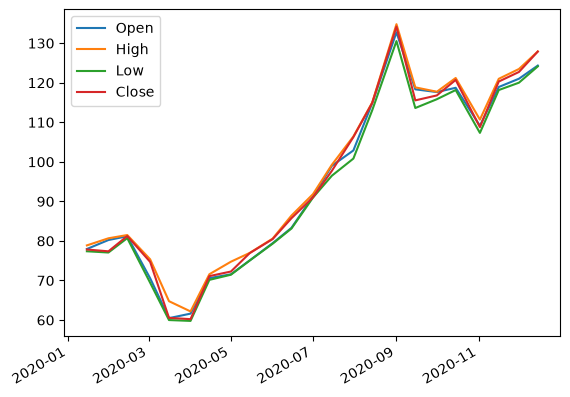

In [22]:
# Reindex the stockData DataFrame using the semiMonthsAdjusted dates
# obtained after applying the adjustDate function to the semiMonths dates,
# and then plot the data
stockData.reindex(semiMonthsAdjusted).plot()

## How to use the resample() method

In [24]:
acresBurned = pd.read_pickle('acresBurned.pkl')
display(acresBurned.head(3))
# Downsample the 'acresBurned' DataFrame by month using the sum aggregation
display(acresBurned.resample(rule='ME').sum().head(3))

,acres_burned
discovery_date,
1992-01-01,1280.76
1992-01-02,122.50
1992-01-03,526.00


,acres_burned
discovery_date,
1992-01-31,26779.35
1992-02-29,73605.86
1992-03-31,115644.53


In [83]:
acresBurned = pd.read_pickle('acresBurned.pkl')
display(acresBurned.head(3))
# Upsample the 'acresBurned' DataFrame by 12 hours using the sum aggregation
# acresBurned.resample(rule='12h').asfreq().head(4)                        # .asfreq()
acresBurned.resample(rule='12h').sum().head(4)            

,acres_burned
discovery_date,
1992-01-01,1280.76
1992-01-02,122.50
1992-01-03,526.00


,acres_burned
discovery_date,
1992-01-01 00:00:00,1280.76
1992-01-01 12:00:00,0.00
1992-01-02 00:00:00,122.50
1992-01-02 12:00:00,0.00


In [89]:
acresBurned = pd.read_pickle('acresBurned.pkl')
display(acresBurned.head(3))
# Upsample the 'acresBurned' DataFrame by 12 hours using forward filling
upsampled = acresBurned.resample(rule='12h').ffill()
display(upsampled.head())

,acres_burned
discovery_date,
1992-01-01,1280.76
1992-01-02,122.50
1992-01-03,526.00


,acres_burned
discovery_date,
1992-01-01 00:00:00,1280.76
1992-01-01 12:00:00,1280.76
1992-01-02 00:00:00,122.50
1992-01-02 12:00:00,122.50
1992-01-03 00:00:00,526.00


## How to use the label and closed parameters when you downsample

In [28]:
acresBurned = pd.read_pickle('acresBurned.pkl')
# Resample the 'acresBurned' DataFrame to quarterly frequency, 
# with right-aligned labels and right-closed intervals, and compute the sum
# We use 'Q' as the resampling frequency, which means we are resampling the data
# to quarters (i.e., 3-month intervals). Other options include 'D' for daily,
# 'W' for weekly, 'M' for monthly, and so on.
# label='right' means the labels for the resampled data should be the end of each quarter. 
# closed='right' means that each interval includes the end point (last day) of the interval.
acresBurned.resample(rule='QE', label='right', closed='right').sum().head()

,acres_burned
discovery_date,
1992-03-31,216029.74
1992-06-30,485118.67
1992-09-30,1293714.71
1992-12-31,129026.79
1993-03-31,141047.95


In [29]:
# Resample the 'acresBurned' DataFrame to quarterly frequency, 
# with left-aligned labels and left-closed intervals, and compute the sum
acresBurned.resample(rule='QE', label='left', closed='left').sum().head()

,acres_burned
discovery_date,
1991-12-31,213086.74
1992-03-31,487341.67
1992-06-30,1290628.71
1992-09-30,132765.79
1992-12-31,139471.71


## How downsampling can improve plots

In [31]:
# Display the first 2 rows of the 'stockData' DataFrame
stockData.head(2)

,Open,High,Low,Close
Date,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502
2020-01-03,74.287498,75.144997,74.125000,74.357498


<Axes: xlabel='Date'>

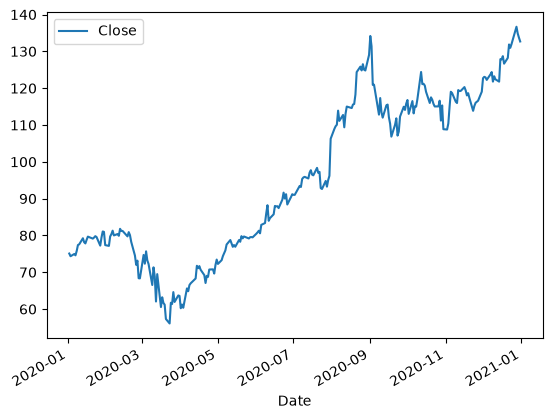

In [32]:
# Generate a line plot of 'Close' column from 'stockData' DataFrame
stockData.plot(y='Close')

<Axes: xlabel='Date'>

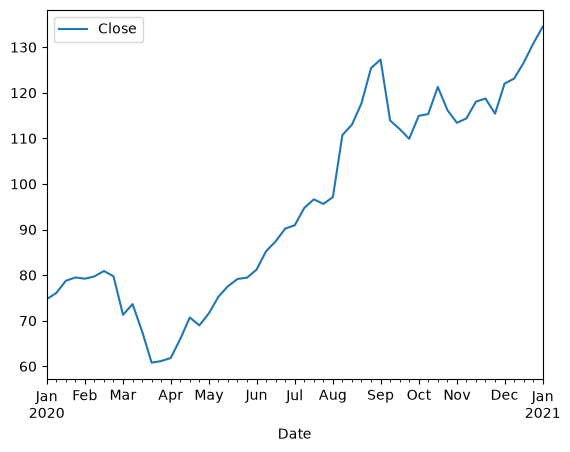

In [33]:
# Resample the data to weekly frequency 
# and calculate the mean of 'Close' column, then generate a line plot
stockData.resample(rule='W').mean().plot(y='Close')

## The concept of rolling windows

,High,Low
Date,,
2020-01-02,75.150002,73.797501
2020-01-03,75.144997,74.125000
2020-01-06,74.989998,73.187500
2020-01-07,75.224998,74.370003
2020-01-08,76.110001,74.290001
2020-01-09,77.607498,76.550003
2020-01-10,78.167503,77.062500
2020-01-13,79.267502,77.787498
2020-01-14,79.392502,78.042503


[Text(18263.0, 0, '01-02'),
 Text(18264.0, 0, '01-03'),
 Text(18267.0, 0, '01-06'),
 Text(18268.0, 0, '01-07'),
 Text(18269.0, 0, '01-08'),
 Text(18270.0, 0, '01-09'),
 Text(18271.0, 0, '01-10'),
 Text(18274.0, 0, '01-13'),
 Text(18275.0, 0, '01-14'),
 Text(18276.0, 0, '01-15'),
 Text(18277.0, 0, '01-16'),
 Text(18278.0, 0, '01-17'),
 Text(18281.0, 0, '01-20'),
 Text(18282.0, 0, '01-21'),
 Text(18283.0, 0, '01-22'),
 Text(18284.0, 0, '01-23'),
 Text(18285.0, 0, '01-24'),
 Text(18288.0, 0, '01-27'),
 Text(18289.0, 0, '01-28'),
 Text(18290.0, 0, '01-29'),
 Text(18291.0, 0, '01-30'),
 Text(18292.0, 0, '01-31')]

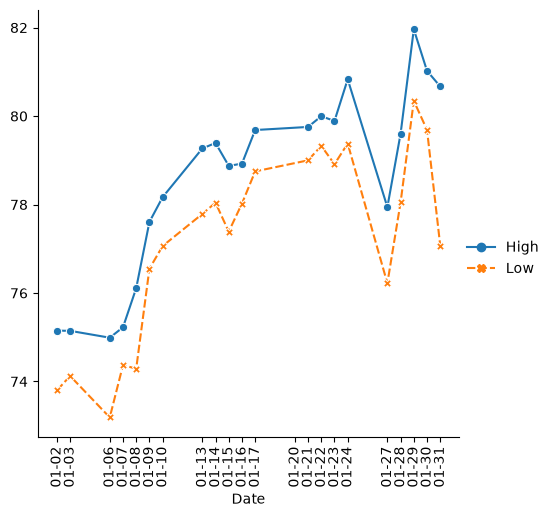

In [35]:
# Extract 'High' and 'Low' columns from stockData for dates up to 01/31/2020
df = stockData[['High','Low']].query('Date <= "01/31/2020"')
display(df)
# Generate a line plot with markers using seaborn's relplot
g = sns.relplot(data=df, kind='line', markers=True)
# Rotate x-axis labels by 90 degrees
for ax in g.axes.flat:
    ax.tick_params('x',labelrotation=90)
# Set custom x-ticks and x-tick labels using pd.date_range and strftime
ax.set_xticks(pd.date_range(start='01/02/2020', end='01/31/2020', freq='B'))
ax.set_xticklabels(pd.date_range(start='01/02/2020', end='01/31/2020', freq='B')
                   .strftime('%m-%d'))

,High,Low
Date,,
2020-01-02,NaN,NaN
2020-01-03,NaN,NaN
2020-01-06,NaN,NaN
2020-01-07,NaN,NaN
2020-01-08,NaN,NaN
2020-01-09,NaN,NaN
2020-01-10,76.056428,74.768930
2020-01-13,76.644642,75.338929
2020-01-14,77.251429,75.898573


[Text(18263.0, 0, '01-02'),
 Text(18264.0, 0, '01-03'),
 Text(18267.0, 0, '01-06'),
 Text(18268.0, 0, '01-07'),
 Text(18269.0, 0, '01-08'),
 Text(18270.0, 0, '01-09'),
 Text(18271.0, 0, '01-10'),
 Text(18274.0, 0, '01-13'),
 Text(18275.0, 0, '01-14'),
 Text(18276.0, 0, '01-15'),
 Text(18277.0, 0, '01-16'),
 Text(18278.0, 0, '01-17'),
 Text(18281.0, 0, '01-20'),
 Text(18282.0, 0, '01-21'),
 Text(18283.0, 0, '01-22'),
 Text(18284.0, 0, '01-23'),
 Text(18285.0, 0, '01-24'),
 Text(18288.0, 0, '01-27'),
 Text(18289.0, 0, '01-28'),
 Text(18290.0, 0, '01-29'),
 Text(18291.0, 0, '01-30'),
 Text(18292.0, 0, '01-31')]

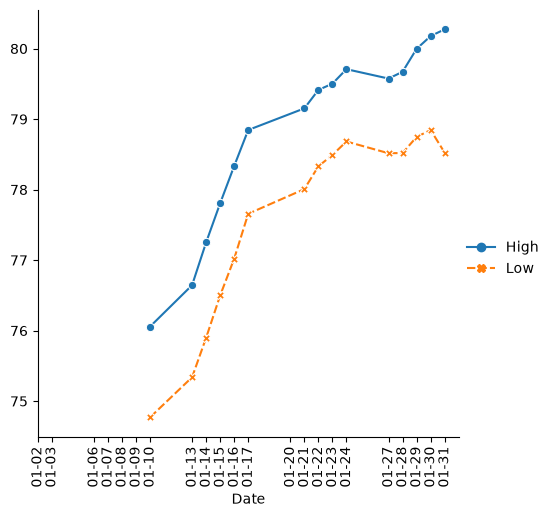

In [36]:
# Extract 'High' and 'Low' columns from stockData for dates up to 01/31/2020
# Apply a rolling window of size 7 to calculate the mean of the values in each window
# min_periods=7 means the rolling mean will only be calculated for windows 
# that contain at least 7 non-NaN values.
df = stockData[['High','Low']].query('Date <= "01/31/2020"') \
                            .rolling(window=7, min_periods=7).mean()
display(df)
# Generate a line plot with markers using seaborn's relplot
g = sns.relplot(data=df, kind='line', markers=True)
for ax in g.axes.flat:
    ax.tick_params('x', labelrotation=90)
# Set custom x-ticks and x-tick labels using pd.date_range and strftime
ax.set_xticks(pd.date_range(start='01/02/2020', end='01/31/2020', freq='B'))
ax.set_xticklabels(pd.date_range(start='01/02/2020', end='01/31/2020', freq='B')
                   .strftime('%m-%d'))

## How to create rolling windows

In [38]:
# Extract 'High' and 'Low' columns from stockData for dates up to 01/31/2020
df = stockData[['High','Low']].query('Date <= "01/31/2020"').rolling(window=7).mean()
# Display the first 8 rows of the resulting DataFrame
df.head(8)

,High,Low
Date,,
2020-01-02,NaN,NaN
2020-01-03,NaN,NaN
2020-01-06,NaN,NaN
2020-01-07,NaN,NaN
2020-01-08,NaN,NaN
2020-01-09,NaN,NaN
2020-01-10,76.056428,74.768930
2020-01-13,76.644642,75.338929


In [39]:
# Extract 'High' and 'Low' columns from stockData for dates up to 01/31/2020
# Compute the rolling mean with a window of 7 and a minimum of 1 period
df = stockData[['High','Low']].query('Date <= "01/31/2020"').rolling(window=7, min_periods=1).mean()
# Display the first 8 rows of the resulting DataFrame
df.head(8)

,High,Low
Date,,
2020-01-02,75.150002,73.797501
2020-01-03,75.147500,73.961251
2020-01-06,75.094999,73.703334
2020-01-07,75.127499,73.870001
2020-01-08,75.323999,73.954001
2020-01-09,75.704582,74.386668
2020-01-10,76.056428,74.768930
2020-01-13,76.644642,75.338929


## How to plot rolling window data

[Text(18271.0, 0, '2020-01-10'),
 Text(18274.0, 0, '2020-01-13'),
 Text(18275.0, 0, '2020-01-14'),
 Text(18276.0, 0, '2020-01-15'),
 Text(18277.0, 0, '2020-01-16'),
 Text(18278.0, 0, '2020-01-17'),
 Text(18281.0, 0, '2020-01-20'),
 Text(18282.0, 0, '2020-01-21'),
 Text(18283.0, 0, '2020-01-22'),
 Text(18284.0, 0, '2020-01-23'),
 Text(18285.0, 0, '2020-01-24'),
 Text(18288.0, 0, '2020-01-27'),
 Text(18289.0, 0, '2020-01-28'),
 Text(18290.0, 0, '2020-01-29'),
 Text(18291.0, 0, '2020-01-30'),
 Text(18292.0, 0, '2020-01-31')]

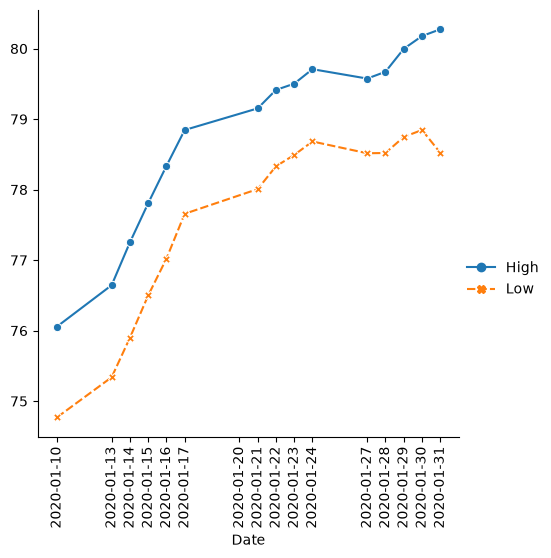

In [41]:
# Extract 'High' and 'Low' columns from stockData for dates up to 01/31/2020
# Compute the rolling mean with a window of 7 and a minimum of 7 periods
df = stockData[['High','Low']].query('Date <= "01/31/2020"').rolling(window=7, min_periods=7).mean()
# Create a line plot using seaborn.relplot with markers
g = sns.relplot(data=df, kind='line', markers=True)
# Rotate x-axis labels by 90 degrees
for ax in g.axes.flat:
    ax.tick_params('x', labelrotation=90)
# Set x-axis ticks and tick labels to be weekdays from 01/10/2020 to 01/31/2020
ax.set_xticks(pd.date_range(start='01/10/2020', end='01/31/2020', freq='B'))
ax.set_xticklabels(pd.date_range(start='01/10/2020', end='01/31/2020', freq='B').strftime('%Y-%m-%d'))

## How to create running totals

In [43]:
# Read data from 'acresBurned.pkl' file and load it into a pandas DataFrame
acresBurned = pd.read_pickle('acresBurned.pkl')
acresBurned.head()

,acres_burned
discovery_date,
1992-01-01,1280.76
1992-01-02,122.50
1992-01-03,526.00
1992-01-04,1150.13
1992-01-05,408.00


In [44]:
# Add a new column 'running_total' to the DataFrame, calculated as the cumulative sum
acresBurned['running_total'] = acresBurned.expanding().sum()
acresBurned.head()

,acres_burned,running_total
discovery_date,,
1992-01-01,1280.76,1280.76
1992-01-02,122.50,1403.26
1992-01-03,526.00,1929.26
1992-01-04,1150.13,3079.39
1992-01-05,408.00,3487.39


## How to plot the running totals

In [46]:
acresBurned = acresBurned.head(10)
# Reset the index of the acresBurned DataFrame using the inplace=True argument
# to modify the DataFrame in place
acresBurned.reset_index(inplace=True)
acresBurned.head(3)

,discovery_date,acres_burned,running_total
0,1992-01-01,1280.76,1280.76
1,1992-01-02,122.50,1403.26
2,1992-01-03,526.00,1929.26


In [47]:
# Reshape the acresBurned DataFrame using pd.melt
# to convert columns into rows, with 'discovery_date' as the identifier variable
# and 'acres_burned' and 'running_total' as the value variables
# Rename the variable column as 'value_type'
acresMelted = pd.melt(acresBurned, id_vars='discovery_date', 
                      value_vars=['acres_burned','running_total'], var_name='value_type')
acresMelted.head(3)

,discovery_date,value_type,value
0,1992-01-01,acres_burned,1280.76
1,1992-01-02,acres_burned,122.50
2,1992-01-03,acres_burned,526.00


C:\Users\afatem\AppData\Local\Temp\ipykernel_25988\235576772.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(xtick_labels)


[Text(0, 0, '1992-01-01'),
 Text(1, 0, '1992-01-02'),
 Text(2, 0, '1992-01-03'),
 Text(3, 0, '1992-01-04'),
 Text(4, 0, '1992-01-05'),
 Text(5, 0, '1992-01-06'),
 Text(6, 0, '1992-01-07'),
 Text(7, 0, '1992-01-08'),
 Text(8, 0, '1992-01-09'),
 Text(9, 0, '1992-01-10')]

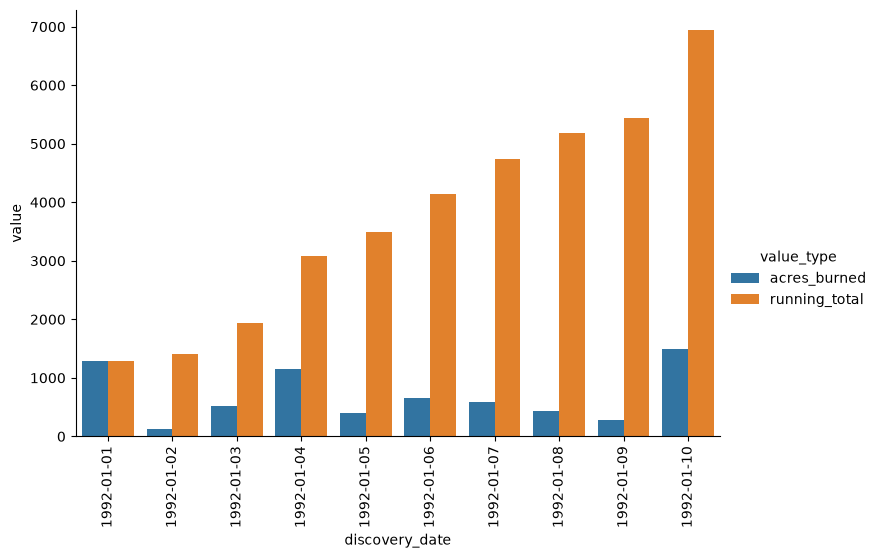

In [48]:
# Create a grouped bar chart using seaborn's catplot
g = sns.catplot(data=acresMelted, kind='bar', x='discovery_date', y='value', hue='value_type', aspect=1.5)
# Rotate x-axis labels by 90 degrees
for ax in g.axes.flat:
    ax.tick_params('x', labelrotation=90)
# Set x-tick labels to unique discovery dates
# First, drop duplicate dates, then convert them to strings
xtick_labels = acresMelted.discovery_date.drop_duplicates().astype(str)
ax.set_xticklabels(xtick_labels)